# Lesson 4: Gridded Data

In this lesson, we are going to start looking at gridded data. This is data that can be stored in a multidimenaional array: think latitude, longitude, and time, although it doesn't have to be these three dimensions (or even three dimensions!). 

In these lessons, when working with general multi-dimensional (gridded) data we'll be using `xarray`, which is a great library with seemingly endless possibilities for processing and analyzing gridded data. The learning curve can be a little steep but stick with it and I guarantee you will learn to love `xarray`.


### Learning outcomes

After this lesson, you should be able to:

1) 
2) 
3)
4) 
5) 


## Raster and Gridded Data

We often refer to higher level (i.e., pre-processed) satellite data as "raster data". Probably, you've come across raster data that represents some enviromental variable in a 2-dimensional (x, y) plane. But raster data is not limited to two dimensions! For example, multi-spectral satellite data has many bands of data on the same x and y plane. Now, we need to think in three dimensions (x, y, spectral band).

The difference between "raster" and "gridded" data is a little blurred, but the main distinction is that raster data is usually considered to be equidistant grids. This means that you don't have to store information about every single latitude and longitude, but it excludes data in certain projections. Here, we are going to use the term gridded data to broadly emcompass, "data that is representing an x and y plane in space". 

When working with general multi-dimensional (gridded) data we'll be using `xarray`:

![Summary Slide](./images/summary_xarray.jpg)

## Working up to Data Cubes

xarray is a library that allows us to manipulate **multidimensional data**. If you've taken linear algebra you might already be familiar with what that means. Multidimensional data is data that is organized using dimensions. Data can be 1-, 2-, or 3-dimensional, and can even be 4-, or 5-dimensional, and higher. Multidimensional data can be difficult to visualize if you haven't worked with it before, so before diving into code let's start by understanding multidimensional data visually first.

Let's start visualizaing a dataset where each number is represented by a little box like this:

![Data Element](./images/data_element.jpg)
<!-- <img src="images/data_element.jpg" width="330" /> -->
<!-- <img src="./images/data_element.jpg" width="200"/> -->

From now on every time you see a little box like this is represents a single data value (ex. an value for wind speed, water temperature, soil moisture, $CO_2$ concentration, etc.)

A one-dimensional dataset would be represented like this:

![1d_array](./images/1d_array.jpg)

Notice how the numbers aren't randomly placed, they are organized by a single dimension. In addition to dimensions we also often talk about the shape of a data array. The **shape** tells us how many values there are along each dimension of the dataset. The array above has a shape of `(9)`, because there are 9 values.

An example of a 1-dimensional dataset might be time series data from an ocean buoy showing water temperatures at each hour over the course of one day. (For the sake of space there are fewer boxes in the array than there are on the plot, but know that each dot on the plot would correspond to one box in a data array).

![1d_array_and_plot](./images/1d_array_and_plot.jpg)

This data is one dimensional because it is organized using one coordinate axis, which in this case is _time_.

If we were to use Python to represent this data we would need to specify one index to get a single value out of the dataset. 

In [3]:
# 1D Python data
water_temp = [15, 64, 23, 42, 34]

print("Third temperature value:", water_temp[2])

Third temperature value: 23


Two dimensional data has two dimensions, meaning data is organized using two sets of coordinates.

![2D Array](./images/2d_array.jpg)

The array above has a shape of `(9, 6)` because there are 9 values along the first dimensions and 6 values along the second dimension.

An example of 2D data might be sea surface temperatures over a region of the Pacific Ocean.

![2D Array with Example Data](./images/2d_array_and_plot.jpg)

In this example the two dimesions are _latitude_ and _longitude_.

If we were to use Python to represent this data we would need to use two indices to get one value out of the dataset.m

In [5]:
# 2D Python data
sst = [[15, 64, 23, 400], [304, 305, 300, 410]]

print("One temperature value:", sst[1][2])

One temperature value: 300


We can continue to make our data into more complex structures by adding additional dimensions. Here is an example of 3-dimensional data.

![3D Array](./images/3d_array.jpg)

In [6]:
co2 = [[[15, 64, 23, 400], [304, 305, 300, 410]], [[15, 64, 23, 400], [304, 305, 300, 410]]]

print("One CO2 value:", co2[0][1][3])

One CO2 value: 410


Now you may think that is the end of it, since we exist in three dimensions, but in math (and computer science) the concept of a "dimension" can continue into 4th, 5th, 6th dimensions and beyond. It doesn't make complete sense to visualize these things in space, but from a math and coding perspective we can continue to organize data into structures that can be described using 4, 5, and 6 dimensions.

The Python access would look like:

In [7]:
fourD = [[[[14, 15, 15], [34, 34, 34]], [[14, 15, 15], [34, 34, 34]]], [[[14, 15, 15], [34, 34, 34]], [[14, 15, 15], [34, 34, 34]]]]

print("One CO2 value:", fourD[1][0][1][2])

One CO2 value: 34


Does that long line of a list of a list of a list of a list look pretty ugly and hard to navigate to you? Good. Then you'll appreciate the benefit of xarray.

## xarray data structure: DataArray

`xarray` is a great (the?) library for working with gridded datasets. It has many built in analysis methods, nice visualization defaults, and it was built by the scientific community. `xarray` is built on top of another library called `numpy`. `xarray` takes the `numpy` arrays and makes them easier to work with by adding labels to the axes. This is a small change but it has a huge effect on the ease of working with data.

`xarray` allows us to work with labelled, multi-dimensional data. What does that mean? There are two parts:
1. **multi-dimensional:** the data is organized into a grid and can have any number of dimensions. For example, data might be organized by latitude, longitude, and altitude (3 dimensions). This is often visually represented as a cube of data.
2. **labelled:** the cube of data isn't just any old cube - each dimension has associated values. For example, we know the values of latitude, longitude, and altitude that the data is describing.

## Anatomy of a DataArray

The first core `xarray` data structure is a `DataArray`. Let's make a `DataArray` with some fake data for air temperature. We will need:
* values for temperature
* we need to know that our data is arranged by `latitude` and `longitude` 
* exactly which latitudes and longitudes our data are showing

In [8]:
import xarray as xr

# Data values
air_temps = [
    [80, 80, 81, 83, 82, 80], [81, 80, 81, 83, 83, 82], [81, 81, 83, 84, 84, 83], 
    [79, 80, 83, 85, 85, 85], [78, 77, 80, 85, 86, 87]
]
# Coordinate values
lats = [36, 37, 38, 39, 40]
lons = [-80, -79, -78, -77, -76, -75]
# Assemble the DataArray
temps = xr.DataArray(data=air_temps, dims=['latitude', 'longitude'], coords=[lats, lons],)

Don't worry too much about every line of the big code block above. You'll rarely ever need to create your own `DataArray`, as the most common thing is to open data from a file. More importantly, let's see what all that code created:

In [9]:
temps

<xarray.DataArray (latitude: 5, longitude: 6)> Size: 240B
array([[80, 80, 81, 83, 82, 80],
       [81, 80, 81, 83, 83, 82],
       [81, 81, 83, 84, 84, 83],
       [79, 80, 83, 85, 85, 85],
       [78, 77, 80, 85, 86, 87]])
Coordinates:
  * latitude   (latitude) int64 40B 36 37 38 39 40
  * longitude  (longitude) int64 48B -80 -79 -78 -77 -76 -75

What has xarray given us? An `xarray` `DataArray`. We get a nice output, and notice that it is clickable. We can see in the output that a `DataArray` has three major components:
1. `data`: values for temperature
2. `dims`: (_short for dimensions_) indicates that our data is arranged by `latitude` and `longitude`
3. `coords`: (_short for coordinates_) the values for latitude and longitude

The figure below shows where to find these three components in the xarray output. We see that this data is organized by latitude and longitude. The data covers 5 latitudes and 6 longitudes. The exact location of our data is shown in the coordinates, and the observed temperature values are listed in the main data array.

![xarray dataarray html output labelled](./images/labelled_html.png)

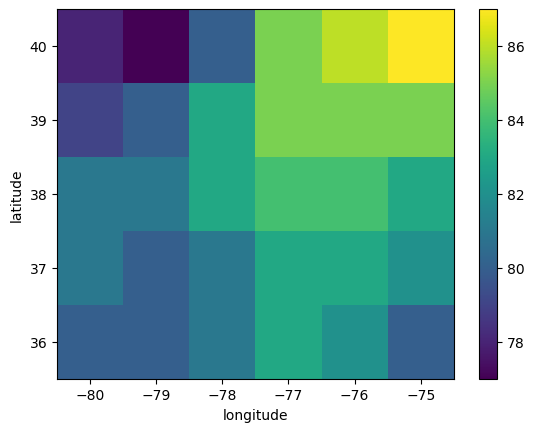

In [10]:
# Easy quick plotting with xarray
temps.plot()

We've created a plot of our temperature data! Each box of data is called a **pixel** and each pixel is colored to show the corresponding temperature value. We can see that the highest tempeatures are in the northeast corner of this plot while the lowest values are in the northwest corner.

And notice 🚨! We don't just have a random set of 30 temperature values. We have temperature values that represent a certain geographic location. Where is this data located? Where in the world is about $36-40^\circ$N and $75-80^\circ$W?

Right about here.

So, if we were to summarize the fake data we just made, we could say that we made data showing: 

> air temperature values over Virginia and Maryland

![study area map](./images/sample_geography.png)

## Summarizing datacube visualization

In the past few minutes we have now seen three different ways to visualize multidimensional data. We have:
1. The output from an xarray DataArray
2. A plot of two dimensional data
3. The graphical representation from earlier in this lesson

One of these three ways of visualizing may click better for you than others, and that's great. Going forward we will use a mixture of these representations, but remember that in the end they all represent the same thing: environmental data.

![2D Data Representations: xarray HTML, plot, schematic](./images/2d_data_representations.jpg)

In [11]:
# Data array attributes
print('DIMS', temps.dims)
print('COORDS', temps.coords)
print('DATA', temps.data)

DIMS ('latitude', 'longitude')
COORDS Coordinates:
  * latitude   (latitude) int64 40B 36 37 38 39 40
  * longitude  (longitude) int64 48B -80 -79 -78 -77 -76 -75
DATA [[80 80 81 83 82 80]
 [81 80 81 83 83 82]
 [81 81 83 84 84 83]
 [79 80 83 85 85 85]
 [78 77 80 85 86 87]]


## 3D DataArrays

Let's add a third dimension to our DataArray: altitude. 

Conceptually:

![Conceptual Drawing 3D Data](./images/fake_data_3d.jpg)

In [ ]:
# Define the data
temperature_3d_values = np.random.randint(0, high=75, size=(3, 4, 6))

# Define the coordinates
altitude = [0, 500, 1000]
lats = [33, 34, 35, 36]
lons = [-122, -121, -120, -119, -118, -117]

# Assemble the DataArray
temperature_3d = xr.DataArray(temperature_3d_values, 
                      dims=['altitude', 'latitude', 'longitude'], 
                      coords=[altitude, lats, lons]
                     )
temperature_3d

# Exercise: anatomty of a data array

The following `DataArray` contains values for wind speeds. 
1. What are the dimensions?
2. What are the coordinates?
3. What is the highest and lowest wind speed in the array?

![example output](./images/example_2d_repr.png)

In [ ]:
## Loading gridded data with xarray



## Indexing and Selecting Values

One of the great things about having labelled data is that we can use the labels to extract a smaller amount of data from a larger dataset. This process of extracting some data from a larger amount of data is called subsetting. **Subsetting** is the process of taking a large dataset and picking out just the bit of data that you need for your analysis. We do this in `xarray` using the `.sel()` selection syntax.

Now often you want to find not just a single value, but data over a larger area. For example, maybe the data file that you downloaded has data for the whole world but you only want data over the state of California. To achieve that we use a `slice()`.

Selecting by label is the most common way to use xarray, but sometimes you still want to use an index. When we talked about selecting data in lists we talked about a data **index**. Indexes let us say "_I want the first, second, and third elements_". `xarray` also lets you select data by index, but the syntax is different. Instead of square brackets we use the `.isel()` method and we give the names of our dimensions as arguments. 

In [18]:
# Get the value of the array where latitude is EQUAL TO 37 and longitude is EQUAL TO -19
temps.sel(latitude=37, longitude=-79)
# temps.sel(latitude=37, longitude=-79).data

<xarray.DataArray ()> Size: 8B
array(80)
Coordinates:
    latitude   int64 8B 37
    longitude  int64 8B -79

In [13]:
# Select all the data between (and including) 37 and 39 degrees north
temps.sel(latitude=slice(37, 39))

<xarray.DataArray (latitude: 3, longitude: 6)> Size: 144B
array([[81, 80, 81, 83, 83, 82],
       [81, 81, 83, 84, 84, 83],
       [79, 80, 83, 85, 85, 85]])
Coordinates:
  * latitude   (latitude) int64 24B 37 38 39
  * longitude  (longitude) int64 48B -80 -79 -78 -77 -76 -75

Notice, how does the shape of this dataset compare to the full dataset? Before we had an array of shape 5 x 6, with 5 latitudes and 6 longitudes. It was a 2-dimensional array. Now we still have a 2-dimensional array, but it is a smaller array. We have an array of shape 3 x 6, with 3 latitudes and 6 longitudes. 
![Graphic of select with slice](./images/select_example1.jpg)

In [15]:
# Using isel
temps.isel(longitude=3, latitude=0)
# temps.isel(latitude=0, longitude=3).data

# temps.isel(longitude=3)

array(83)

![Graphic of select from the exampe](./images/select_example2.jpg)

In [2]:
# We can also select DataArray values using numpy-like selection
# But often more intuitive to use sel and isel
temps[0, 3]  # returns a DataArray
# temps[0, 3].data # returns a numpy array 

# temps[:, 0:2]

NameError: name 'temps' is not defined

## Exercise: indexing and slicing

What is the shape of the output DataArray in each of the following selections? Use (latitude, longitude) order

1. `temps.sel(latitude=38, longitude=-75)`

2. `temps.sel(latitude=0)`

3. `temps.sel(longitude=slice(-79, -78))`

What would be the output sst values of the following lines of code?

1. `sst.isel(latitude=2, longitude=1)`
2. `sst.sel(latitude=38, longitude=-21)`
3. `sst.isel(latitude=2).sel(longitude=-21)`


## xarray data structure: Dataset

The other core data structure in `xarray` is a `Dataset`, which is a group of `DataArray`s.

To look at a `Dataset` let's go back to our example of air temperature in Virginia and Maryland. Let's say that in addition to air temperature temperature we also have data for humidity.

In [3]:
# Create DataArray for chlorophyll-a
windspeed_values = np.random.uniform(4, high=13, size=(5, 6))
# Assemble the Dataset
air_dataset = xr.Dataset(
    data_vars={"temperature": temps, "wind_speed": (("latitude", "longitude"), windspeed_values)}
)

air_dataset

NameError: name 'np' is not defined

In the output we see that we have a new section: Data Variables where both temperature and wind speed are listed! The coordinates and dimensions are also maintained.

![xarray dataset html output labelled](./images/labelled_html_dataset.png)

In [4]:
# Access a DataArray containing the temperature data
air_dataset['temperature']

NameError: name 'air_dataset' is not defined

## Loading real data with xarray

The small dataset we made manually in the first part of this notebook is quite useful for learning. Usually, though, you won't be making your own data, you'll be opening other datasets. Let's try an example of that using a local file. Here we open up the dataset [NASA MUR](https://podaac.jpl.nasa.gov/dataset/MUR25-JPL-L4-GLOB-v04.2). This is a sea surface temperature dataset. 

We are opening up a MUR file stored locally, but you could re-download this file yourself from earthdata search.

## Metadata

Further reading:

Other xarray tutorials:
* [UW Geohackweek](https://geohackweek.github.io/nDarrays/)
* [Oceanhackweek/Scipy 2020](https://xarray-contrib.github.io/xarray-tutorial/)